In [9]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from google.colab import files

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [10]:
# Upload your cleaned CSV file
from google.colab import files
uploaded = files.upload()

# Get the filename
filename = next(iter(uploaded))

# Load the data
import pandas as pd
df = pd.read_csv(filename)

# Display first few rows
df.head()

Saving cleaned_dataset.csv to cleaned_dataset.csv


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53.0,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14.0,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64.0,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2.0,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73.0,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23.0,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90.0,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49.0,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49.0,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31.0,PayPal,Annually


In [11]:
# Basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3897 entries, 0 to 3896
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3897 non-null   int64  
 1   Age                       3897 non-null   int64  
 2   Gender                    3897 non-null   object 
 3   Item Purchased            3897 non-null   object 
 4   Category                  3897 non-null   object 
 5   Purchase Amount (USD)     3897 non-null   float64
 6   Location                  3897 non-null   object 
 7   Size                      3897 non-null   object 
 8   Color                     3897 non-null   object 
 9   Season                    3897 non-null   object 
 10  Review Rating             3897 non-null   float64
 11  Subscription Status       3897 non-null   object 
 12  Payment Method            3897 non-null   object 
 13  Shipping Type             3897 non-null   object 

In [12]:
# Check for missing values (though data is cleaned, good to verify)
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64


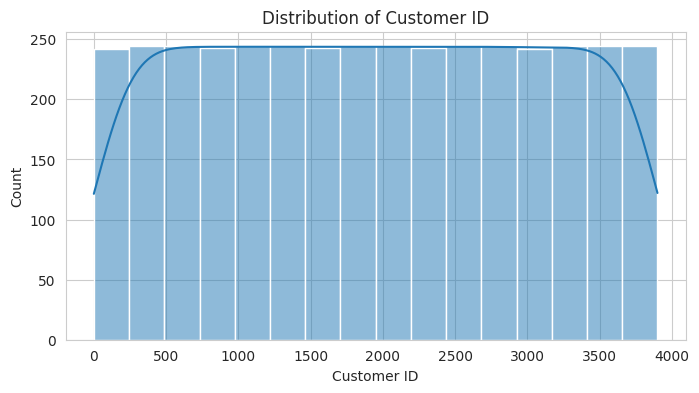

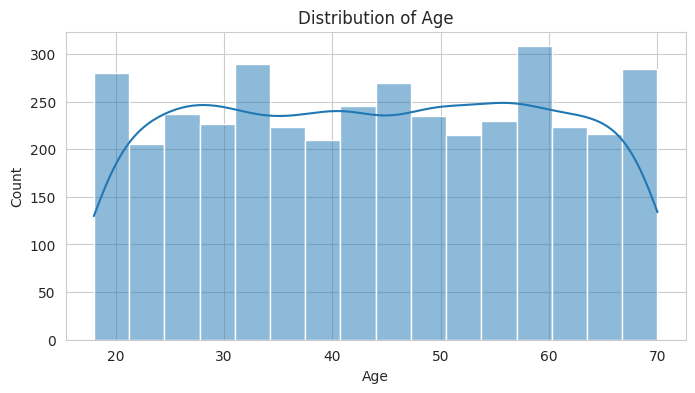

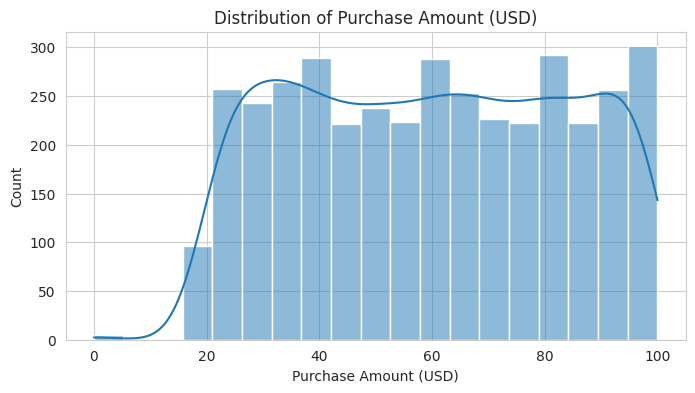

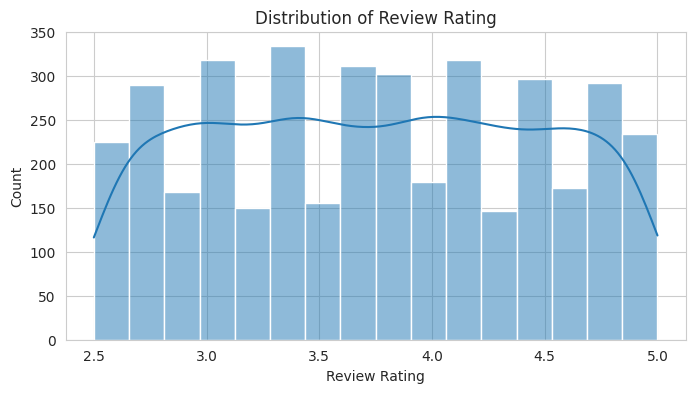

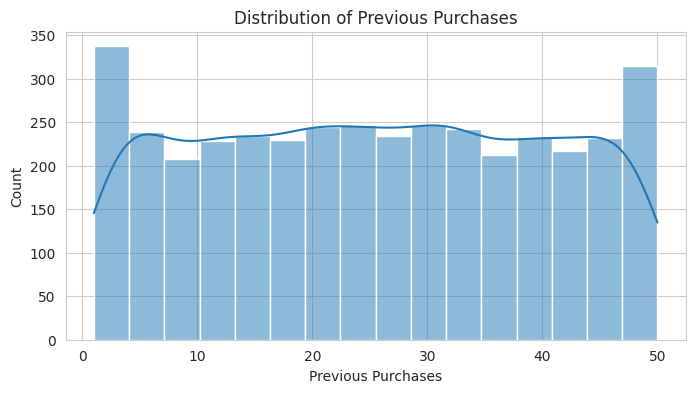

In [13]:
# Visualize distribution of numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')     # Shows the distribution of the graphs of each column in the dataset
    plt.show()

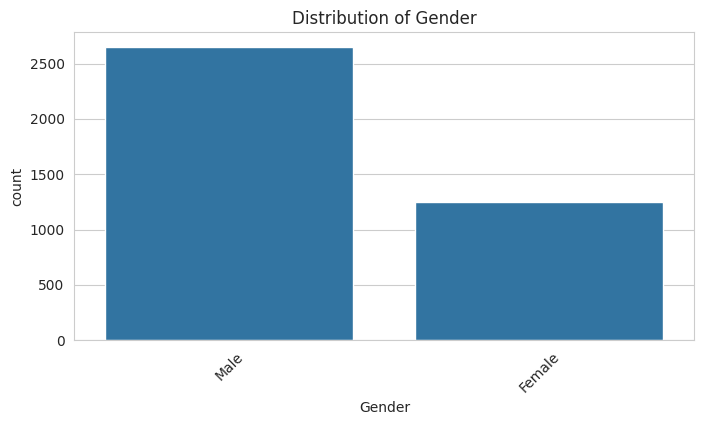

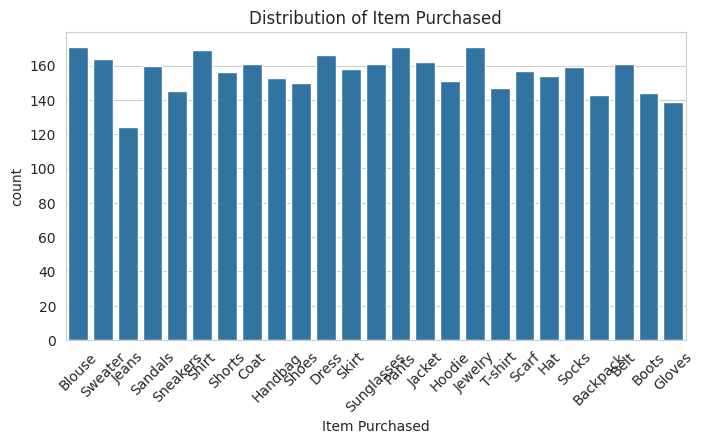

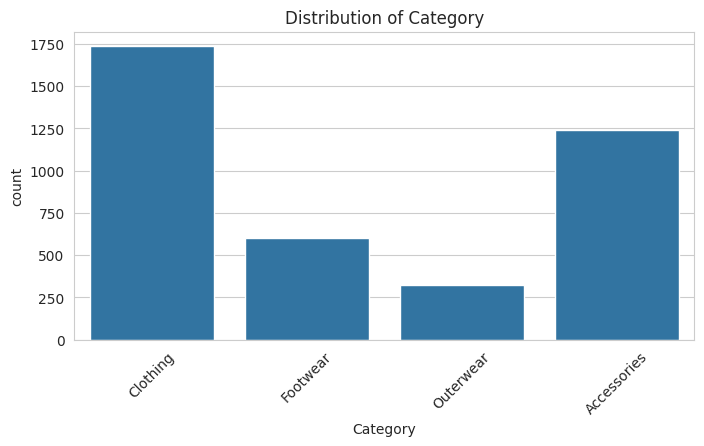

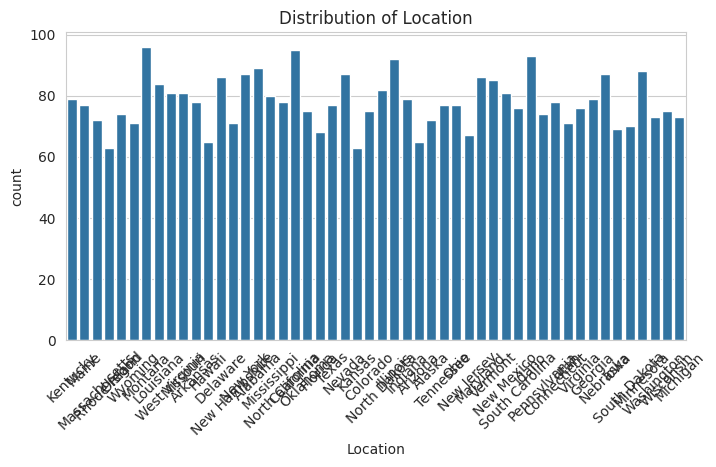

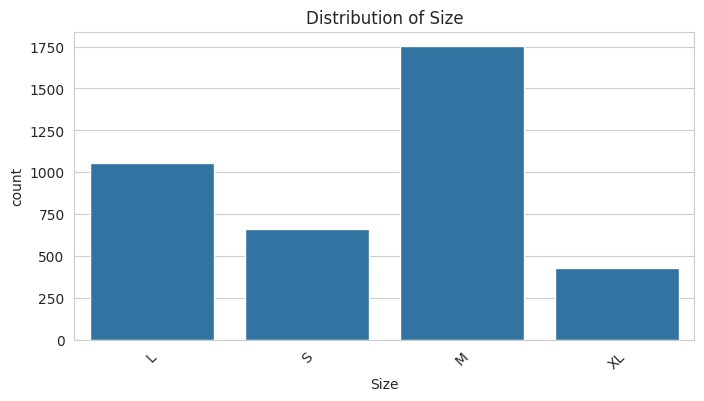

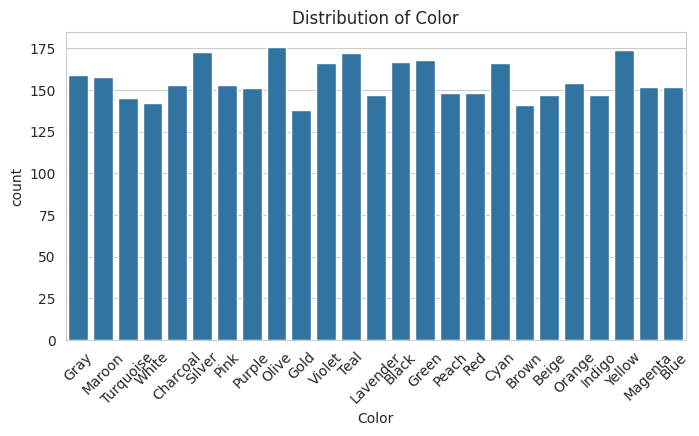

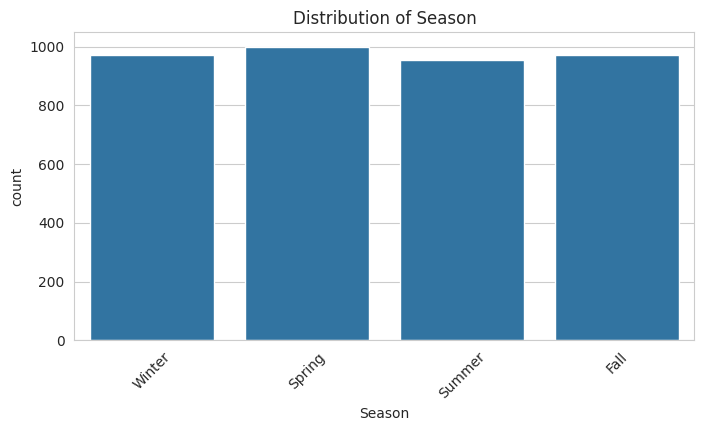

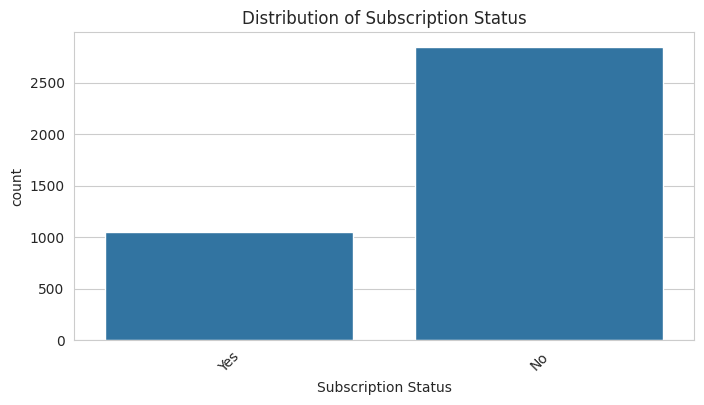

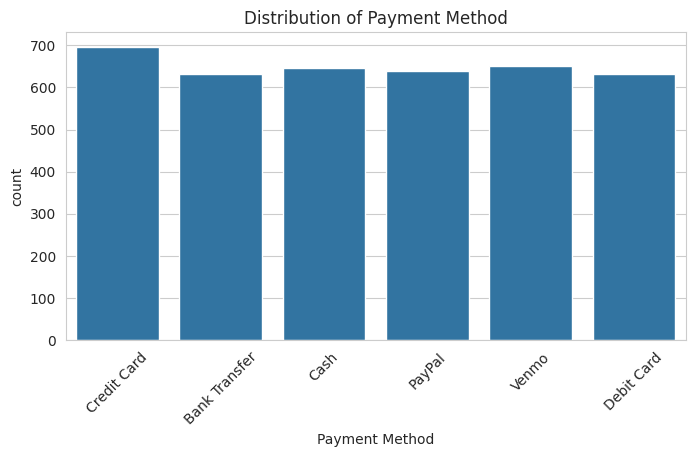

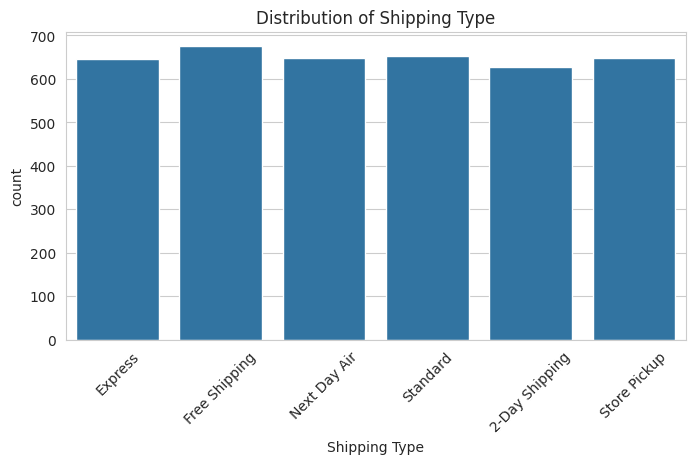

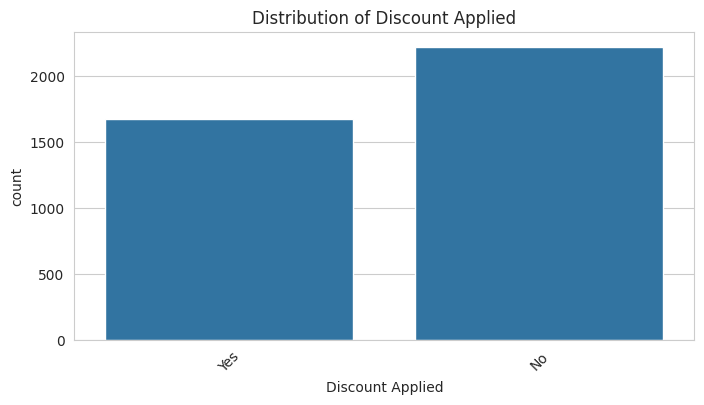

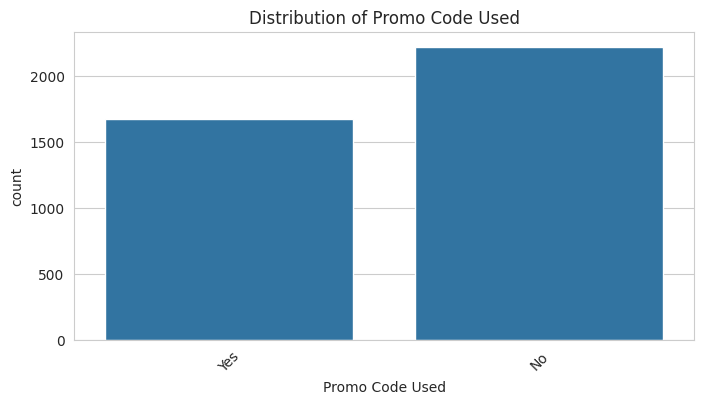

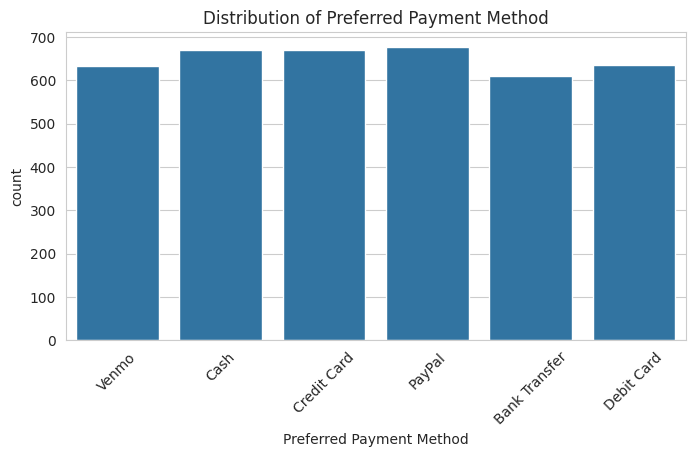

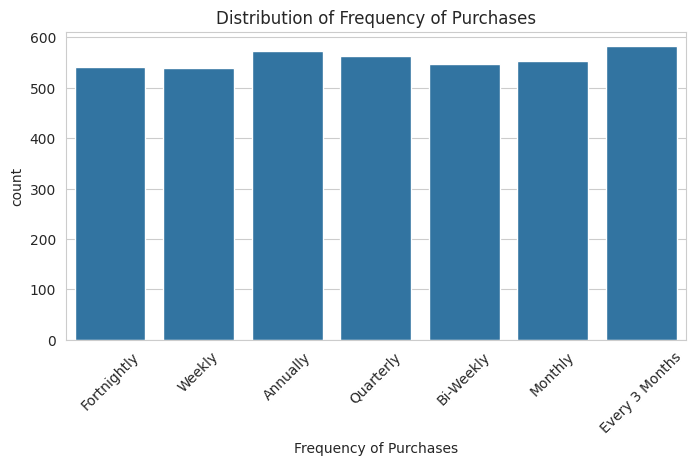

In [14]:
# Visualize categorical features
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')       # Shows the distribution of the graphs of each column in the dataset
    plt.xticks(rotation=45)
    plt.show()

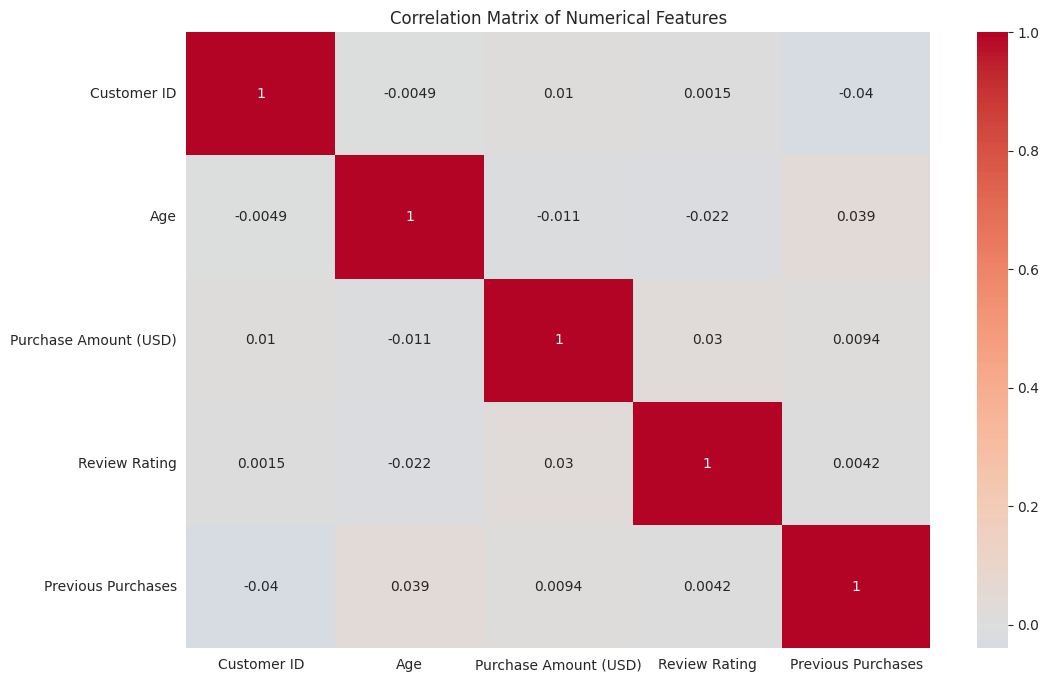

In [15]:
# Correlation matrix for numerical features
plt.figure(figsize=(12, 8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [28]:
# Display all column names in your DataFrame
print("Columns in your dataset:")
print(df.columns.tolist())

Columns in your dataset:
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Payment Method', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Preferred Payment Method', 'Frequency of Purchases', 'Cluster_KMeans', 'Cluster_Hierarchical']


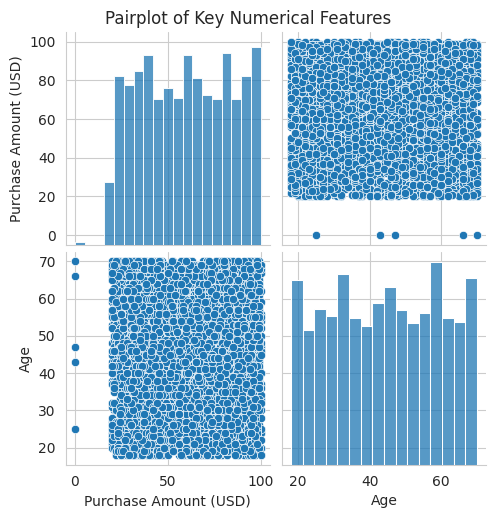

In [17]:
# Pairplot of key numerical features (select 4-5 most important)
key_features = ['Item Purchased', 'Purchase Amount (USD)', 'Age', 'Frequency of Purchases']
sns.pairplot(df[key_features])
plt.suptitle('Pairplot of Key Numerical Features', y=1.02)
plt.show()

In [29]:
# Select features for clustering (adjust based on your dataset)
clustering_features = ['Purchase Amount (USD)', 'Age', 'Previous Purchases']

# Extract the features
X = df[clustering_features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for visualization
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)

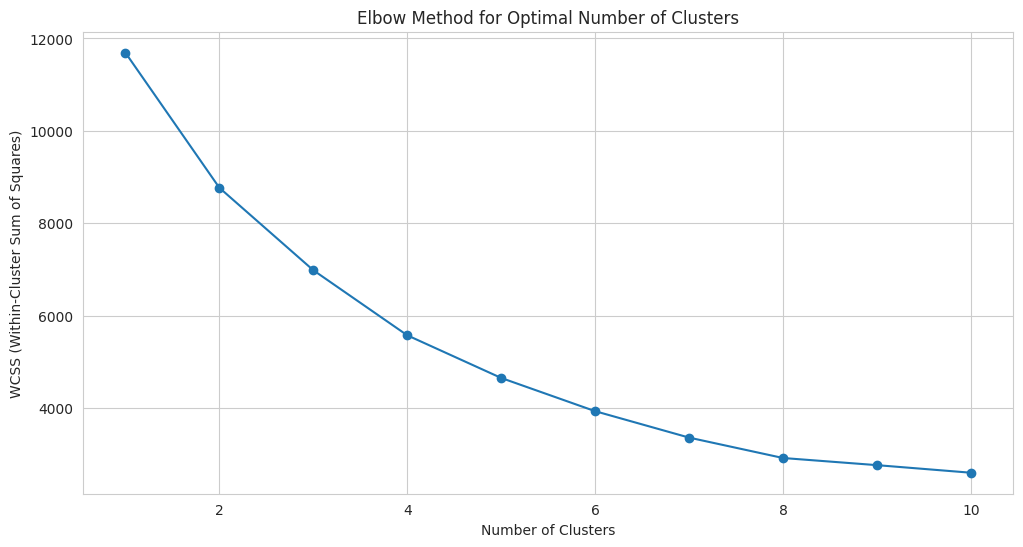

In [30]:
# Elbow method to find optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.show()

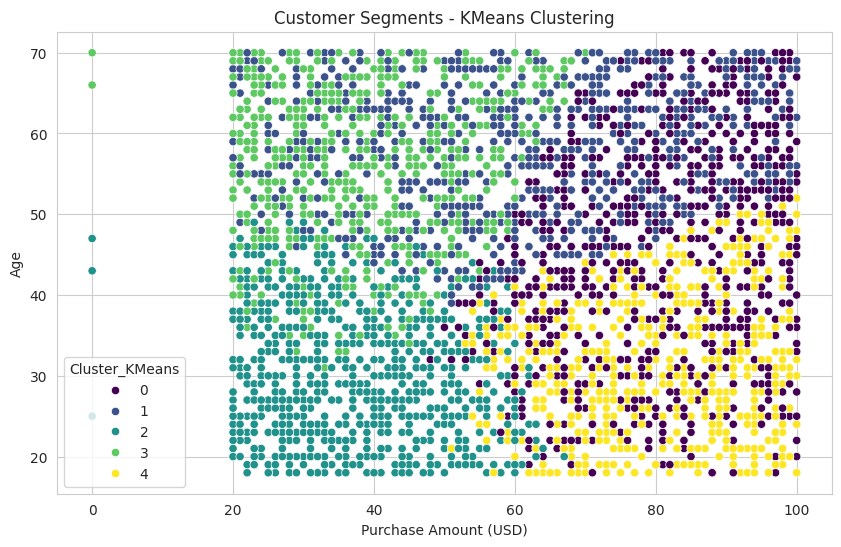

In [20]:
# Apply K-Means clustering with optimal number of clusters
optimal_k = 5  # Change based on your elbow curve
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
clusters_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df['Cluster_KMeans'] = clusters_kmeans

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Purchase Amount (USD)', y='Age', hue='Cluster_KMeans', palette='viridis')
plt.title('Customer Segments - KMeans Clustering')
plt.show()

Cluster Profiles (KMeans):
                Purchase Amount (USD)        Age  Previous Purchases
Cluster_KMeans                                                      
0                           80.664352  44.841435           39.368056
1                           61.385836  58.008547           12.304029
2                           37.733010  30.314320           22.502427
3                           38.684432  55.492286           36.760168
4                           80.090103  30.995569           14.688331


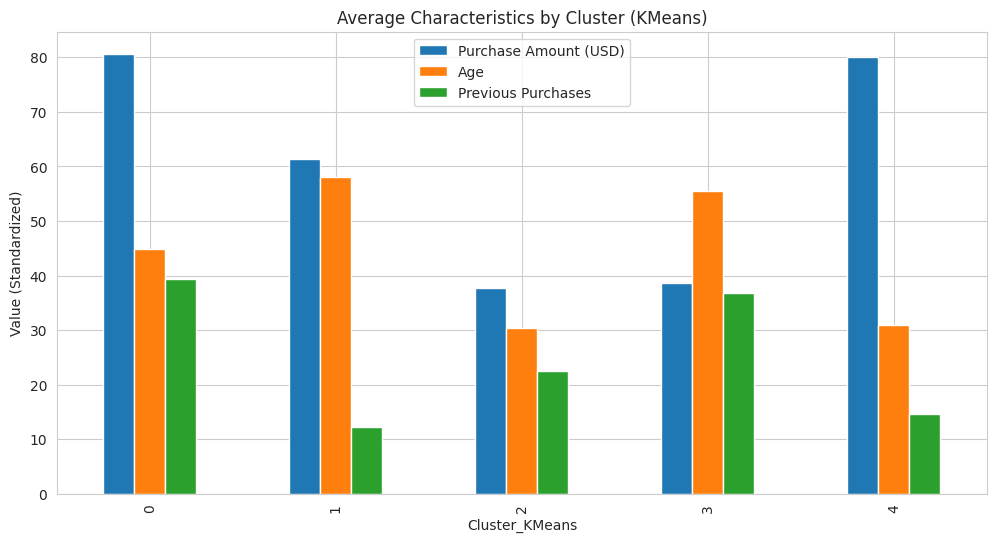

In [21]:
# Analyze cluster characteristics
cluster_profile_kmeans = df.groupby('Cluster_KMeans')[clustering_features].mean()
print("Cluster Profiles (KMeans):")
print(cluster_profile_kmeans)

# Visualize cluster profiles
cluster_profile_kmeans.plot(kind='bar', figsize=(12, 6))
plt.title('Average Characteristics by Cluster (KMeans)')
plt.ylabel('Value (Standardized)')
plt.show()

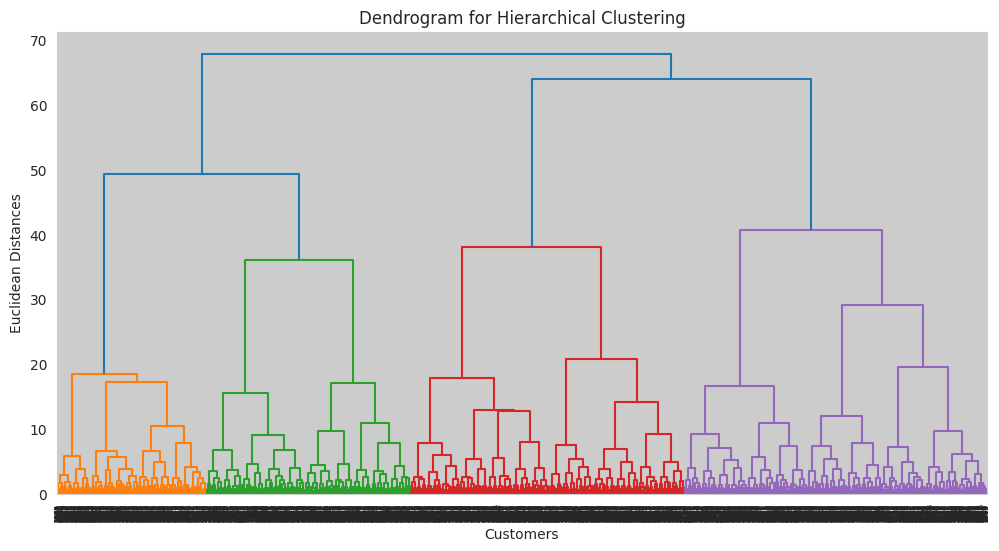

In [22]:
# Dendrogram to determine number of clusters for hierarchical clustering
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.show()

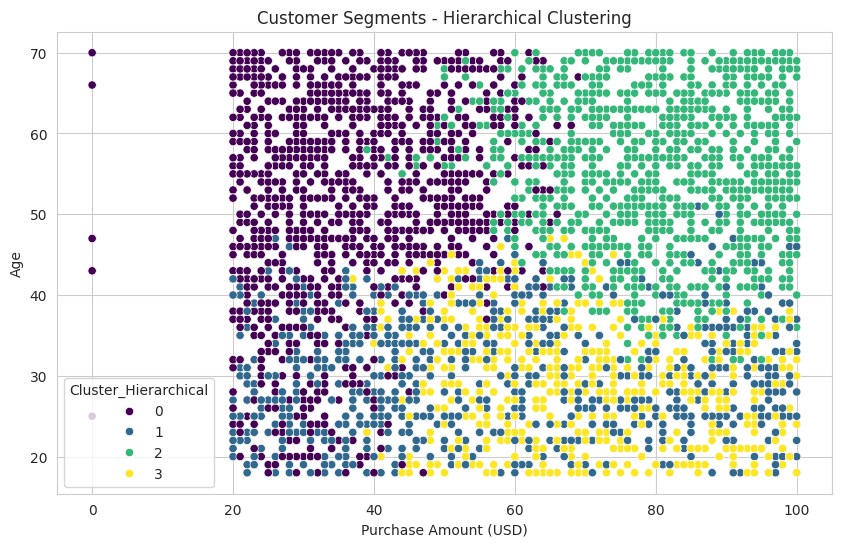

In [23]:
# Apply Agglomerative Clustering
optimal_h = 4  # Change based on your dendrogram
agg_clustering = AgglomerativeClustering(n_clusters=optimal_h, metric='euclidean', linkage='ward')
clusters_hierarchical = agg_clustering.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df['Cluster_Hierarchical'] = clusters_hierarchical

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Purchase Amount (USD)', y='Age', hue='Cluster_Hierarchical', palette='viridis')
plt.title('Customer Segments - Hierarchical Clustering')
plt.show()

Cluster Profiles (Hierarchical):
                      Purchase Amount (USD)        Age  Previous Purchases
Cluster_Hierarchical                                                      
0                                 37.458136  51.285940           21.359400
1                                 57.750292  29.994166           38.519253
2                                 79.976440  54.915358           26.549738
3                                 70.536624  29.004777           13.230892


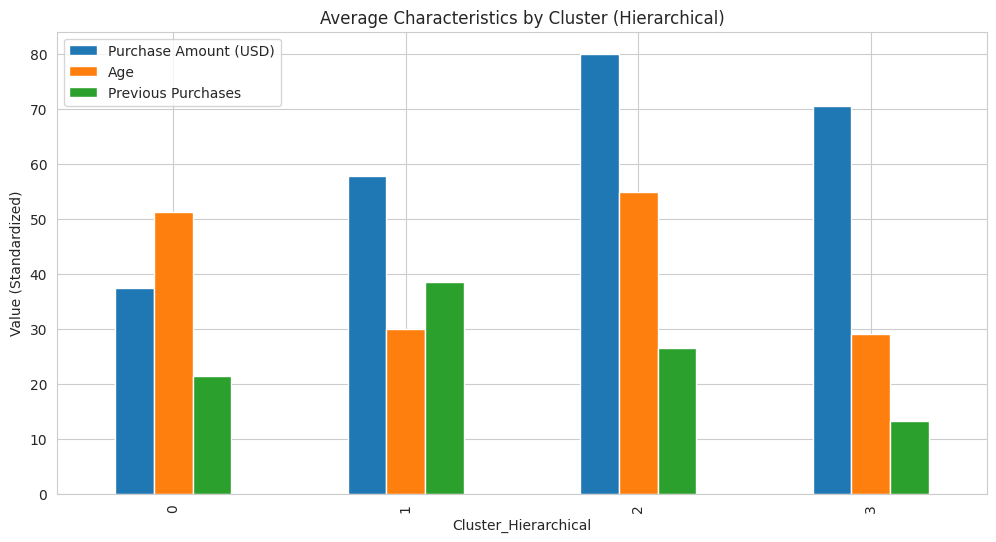

In [24]:
# Analyze cluster characteristics
cluster_profile_hierarchical = df.groupby('Cluster_Hierarchical')[clustering_features].mean()
print("Cluster Profiles (Hierarchical):")
print(cluster_profile_hierarchical)

# Visualize cluster profiles
cluster_profile_hierarchical.plot(kind='bar', figsize=(12, 6))
plt.title('Average Characteristics by Cluster (Hierarchical)')
plt.ylabel('Value (Standardized)')
plt.show()

In [33]:
# Compare the two clustering methods
print("Silhouette Score - KMeans:", silhouette_score(X_scaled, clusters_kmeans))
print("Silhouette Score - Hierarchical:", silhouette_score(X_scaled, clusters_hierarchical))

# Cross-tabulation of clusters from both methods
print("\nCluster Assignment Comparison:")
print(pd.crosstab(df['Cluster_KMeans'], df['Cluster_Hierarchical'], margins=True))

Silhouette Score - KMeans: 0.26697396197952605
Silhouette Score - Hierarchical: 0.21688588230572609

Cluster Assignment Comparison:
Cluster_Hierarchical     0    1     2    3   All
Cluster_KMeans                                  
0                        0  354   502    8   864
1                      402    0   383   34   819
2                      345  357     0  122   824
3                      516   88   109    0   713
4                        3   58   152  464   677
All                   1266  857  1146  628  3897


In [34]:
# Save the clustered data for further analysis
df.to_csv('customer_data_with_clusters.csv', index=False)
files.download('customer_data_with_clusters.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>